# Top 10 des plus grandes villes africaines

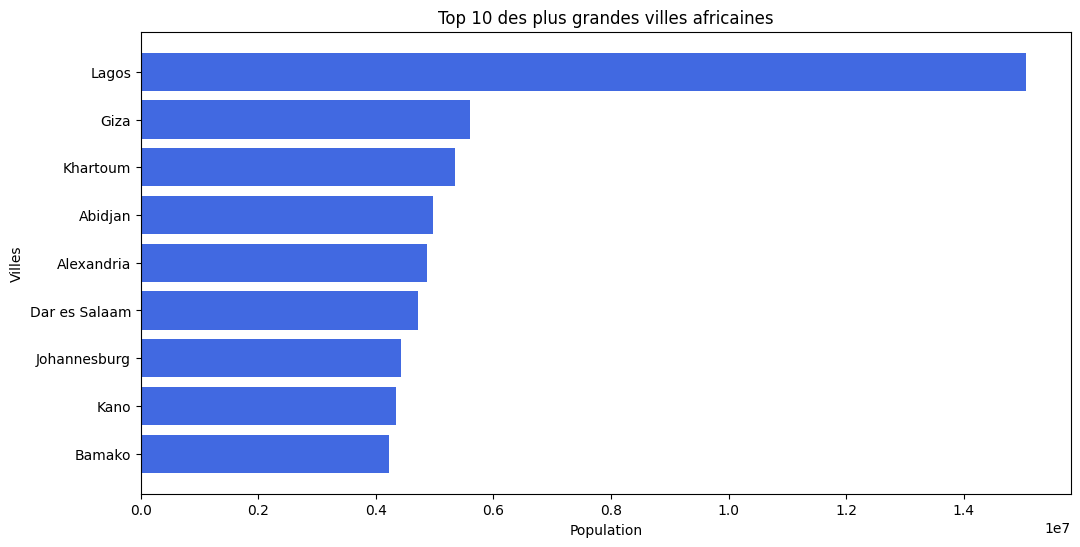

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df_cities = pd.read_csv("biggest_cities.csv")

top_cities = df_cities.sort_values(by="population", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_cities["cityLabel"], top_cities["population"], color="royalblue")
plt.xlabel("Population (en unités de 10M)")
plt.ylabel("Villes")
plt.title("Top 10 des plus grandes villes africaines")
plt.gca().invert_yaxis()
plt.show()


# Répartition des villes par pays

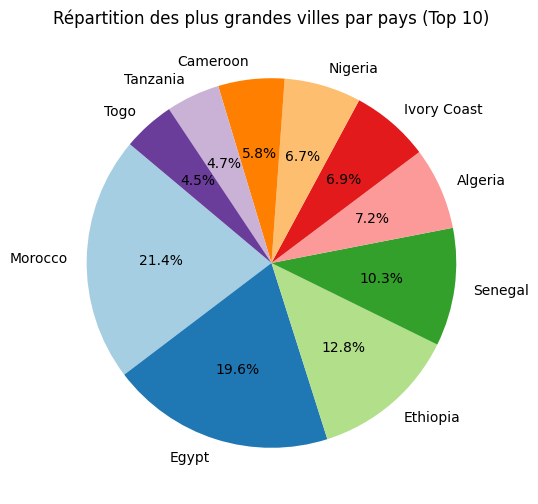

In [2]:
country_counts = df_cities["countryLabel"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Répartition des plus grandes villes par pays (Top 10)")
plt.show()


# Analyse des routes et infrastructures

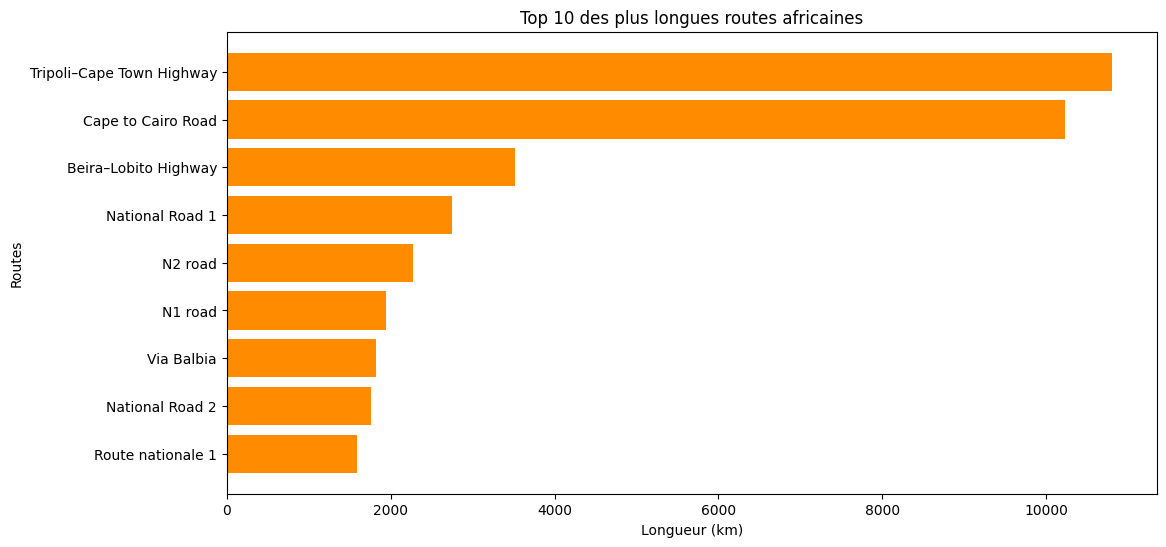

In [3]:
df_roads = pd.read_csv("longest_roads.csv")

# suppr doublons (chaque route est listée plusieurs fois selon les pays
df_roads_unique = df_roads.drop_duplicates(subset=["roadLabel", "length"])

top_roads = df_roads_unique.sort_values(by="length", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_roads["roadLabel"], top_roads["length"], color="darkorange")
plt.xlabel("Longueur (km)")
plt.ylabel("Routes")
plt.title("Top 10 des plus longues routes africaines")
plt.gca().invert_yaxis()
plt.show()


# Nombre de routes principales par pays

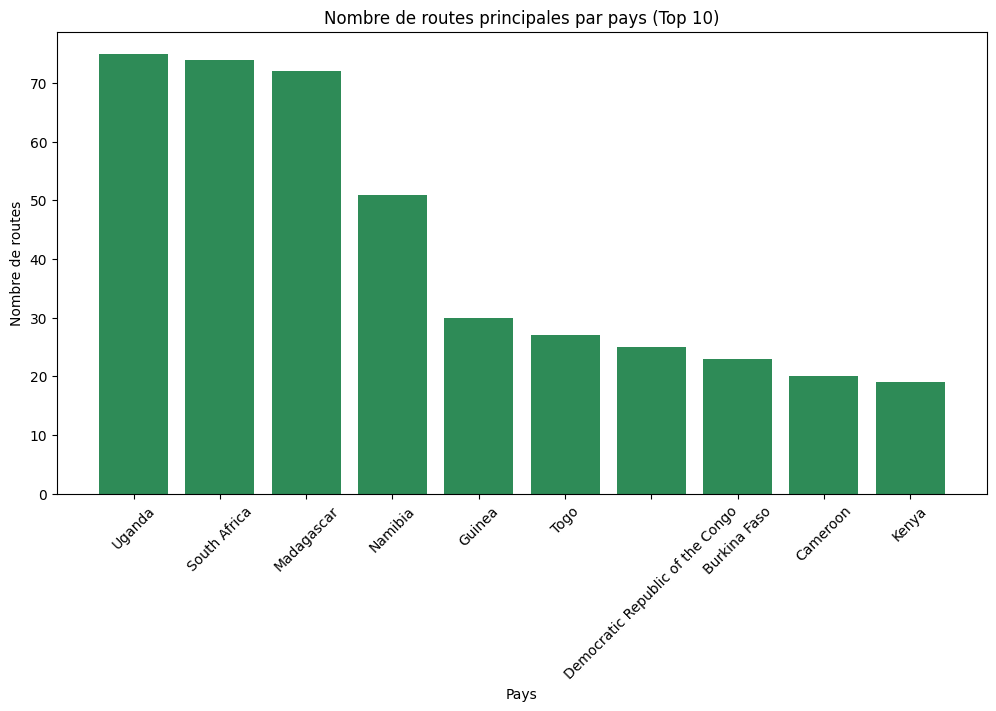

In [4]:
country_road_counts = df_roads["countryLabel"].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(country_road_counts.index, country_road_counts.values, color="seagreen")
plt.xlabel("Pays")
plt.ylabel("Nombre de routes")
plt.title("Nombre de routes principales par pays (Top 10)")
plt.xticks(rotation=45)
plt.show()


# Analyse de l'évolution urbaine

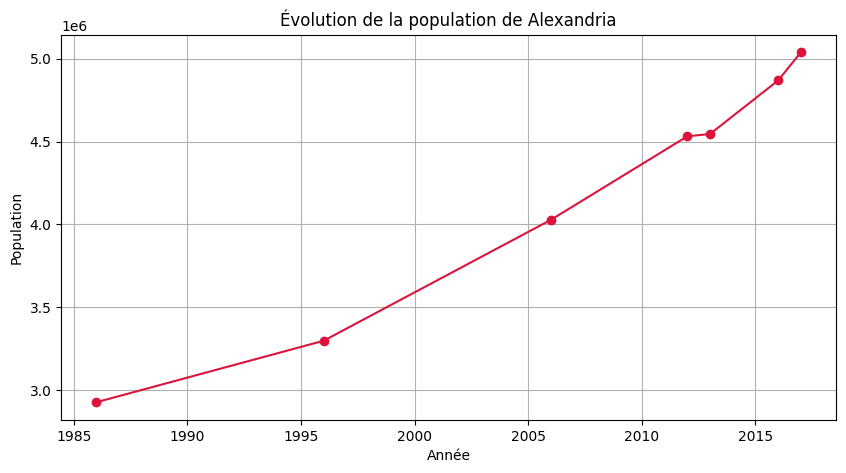

In [5]:
df_urban = pd.read_csv("urban_evolution.csv")

# convertir la colonne year en format datetime
df_urban["year"] = pd.to_datetime(df_urban["year"]).dt.year

# exemple d'Alexandria
city = "Alexandria"
df_city = df_urban[df_urban["cityLabel"] == city]

plt.figure(figsize=(10, 5))
plt.plot(df_city["year"], df_city["population"], marker="o", linestyle="-", color="crimson")
plt.xlabel("Année")
plt.ylabel("Population")
plt.title(f"Évolution de la population de {city}")
plt.grid(True)
plt.show()


# Analyse de l'évolution urbaine (multiville)

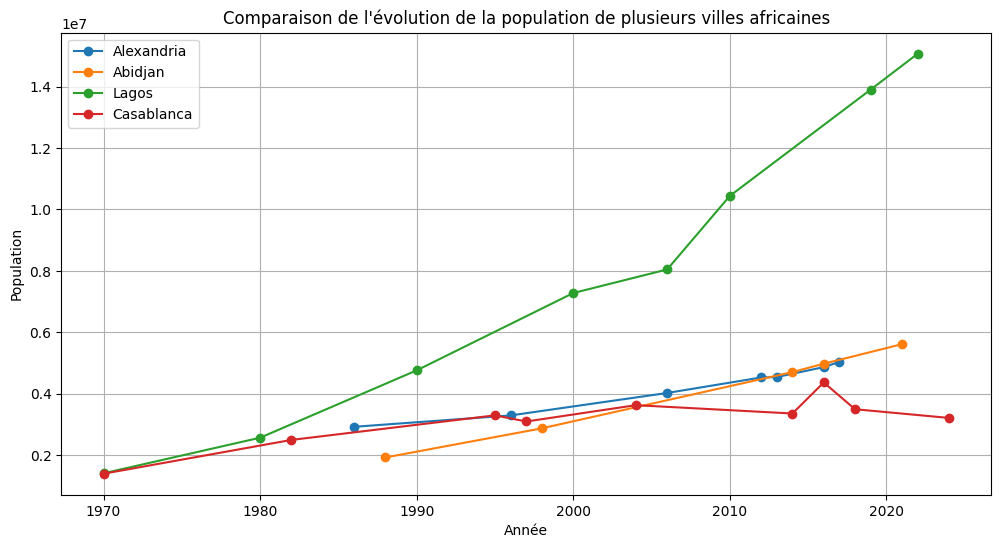

In [7]:
selected_cities = ["Alexandria", "Abidjan", "Lagos", "Casablanca"]
plt.figure(figsize=(12, 6))

for city in selected_cities:
    df_city = df_urban[df_urban["cityLabel"] == city]
    plt.plot(df_city["year"], df_city["population"], marker="o", linestyle="-", label=city)

plt.xlabel("Année")
plt.ylabel("Population")
plt.title("Comparaison de l'évolution de la population de plusieurs villes africaines")
plt.legend()
plt.grid(True)
plt.show()
